<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Further Resources](03.13-Further-Resources.ipynb) | [Contents](Index.ipynb) | [Simple Line Plots](04.01-Simple-Line-Plots.ipynb) >

# Visualization with Matplotlib / Matplotlib数据可视化

We'll now take an in-depth look at the Matplotlib package for visualization in Python.
Matplotlib is a multi-platform data visualization library built on NumPy arrays, and designed to work with the broader SciPy stack.
It was conceived by John Hunter in 2002, originally as a patch to IPython for enabling interactive MATLAB-style plotting via gnuplot from the IPython command line.
IPython's creator, Fernando Perez, was at the time scrambling to finish his PhD, and let John know he wouldn’t have time to review the patch for several months.
John took this as a cue to set out on his own, and the Matplotlib package was born, with version 0.1 released in 2003.
It received an early boost when it was adopted as the plotting package of choice of the Space Telescope Science Institute (the folks behind the Hubble Telescope), which financially supported Matplotlib’s development and greatly expanded its capabilities.

One of Matplotlib’s most important features is its ability to play well with many operating systems and graphics backends.
Matplotlib supports dozens of backends and output types, which means you can count on it to work regardless of which operating system you are using or which output format you wish.
This cross-platform, everything-to-everyone approach has been one of the great strengths of Matplotlib.
It has led to a large user base, which in turn has led to an active developer base and Matplotlib’s powerful tools and ubiquity within the scientific Python world.

In recent years, however, the interface and style of Matplotlib have begun to show their age.
Newer tools like ggplot and ggvis in the R language, along with web visualization toolkits based on D3js and HTML5 canvas, often make Matplotlib feel clunky and old-fashioned.
Still, I'm of the opinion that we cannot ignore Matplotlib's strength as a well-tested, cross-platform graphics engine.
Recent Matplotlib versions make it relatively easy to set new global plotting styles (see [Customizing Matplotlib: Configurations and Style Sheets](04.11-Settings-and-Stylesheets.ipynb)), and people have been developing new packages that build on its powerful internals to drive Matplotlib via cleaner, more modern APIs—for example, Seaborn (discussed in [Visualization With Seaborn](04.14-Visualization-With-Seaborn.ipynb)), [ggpy](http://yhat.github.io/ggpy/), [HoloViews](http://holoviews.org/), [Altair](http://altair-viz.github.io/), and even Pandas itself can be used as wrappers around Matplotlib's API.
Even with wrappers like these, it is still often useful to dive into Matplotlib's syntax to adjust the final plot output.
For this reason, I believe that Matplotlib itself will remain a vital piece of the data visualization stack, even if new tools mean the community gradually moves away from using the Matplotlib API directly.

🐍 Matplotlib 是建立在 NumPy 数组基础上的多平台数据可视化程序库，最初被设计用于完善 SciPy 的生态环境。

🐍 Matplotlib 最重要的特性之一就是具有良好的操作系统兼容性和图形显示底层接口兼容性（graphics backend）。这种跨平台、面面俱到的特点已经成为Matplotlib 最强大的功能之一。

## General Matplotlib Tips / Matplotlib常用技巧

Before we dive into the details of creating visualizations with Matplotlib, there are a few useful things you should know about using the package.

### Importing Matplotlib / 导入

Just as we use the ``np`` shorthand for NumPy and the ``pd`` shorthand for Pandas, we will use some standard shorthands for Matplotlib imports:

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt

The ``plt`` interface is what we will use most often, as we shall see throughout this chapter.

### Setting Styles / 设置绘图样式

We will use the ``plt.style`` directive to choose appropriate aesthetic styles for our figures.
Here we will set the ``classic`` style, which ensures that the plots we create use the classic Matplotlib style:

In [2]:
plt.style.use('classic')

Throughout this section, we will adjust this style as needed.
Note that the stylesheets used here are supported as of Matplotlib version 1.5; if you are using an earlier version of Matplotlib, only the default style is available.
For more information on stylesheets, see [Customizing Matplotlib: Configurations and Style Sheets](04.11-Settings-and-Stylesheets.ipynb).

### ``show()`` or No ``show()``? How to Display Your Plots / 用不用show()？如何显示图形

A visualization you can't see won't be of much use, but just how you view your Matplotlib plots depends on the context.
The best use of Matplotlib differs depending on how you are using it; roughly, the three applicable contexts are using Matplotlib in a script, in an IPython terminal, or in an IPython notebook.

🐍 Matplotlib 的最佳实践与你使用的开发环境有关: 三种开发环境，分别是脚本、IPython shell 和 IPython Notebook

#### Plotting from a script / 在脚本中画图

If you are using Matplotlib from within a script, the function ``plt.show()`` is your friend.

🐍 如果你在一个脚本文件中使用 Matplotlib，那么显示图形的时候必须使用 plt.show()。

``plt.show()`` starts an event loop, looks for all currently active figure objects, and opens one or more interactive windows that display your figure or figures.

So, for example, you may have a file called *myplot.py* containing the following:

```python
# ------- file: myplot.py ------
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)

plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))

plt.show()
```

You can then run this script from the command-line prompt, which will result in a window opening with your figure displayed:

🐍 从prompt命令行工具中执行这个脚本，然后会看到一个新窗口，里面会显示你的图形

🐍 环境和路径：(fyp2023) PS B:\04_Beginner\01_GitHub\fypbjchina2023\b_PythonDSHB\Chapter04>

```
>>> python b04.00_myplot.py
```
🐍 从Ipython工具中执行这个脚本

```
>>> %run b04.00_myplot.py
```

The ``plt.show()`` command does a lot under the hood, as it must interact with your system's interactive graphical backend.
The details of this operation can vary greatly from system to system and even installation to installation, but matplotlib does its best to hide all these details from you.

One thing to be aware of: the ``plt.show()`` command should be used *only once* per Python session, and is most often seen at the very end of the script.
Multiple ``show()`` commands can lead to unpredictable backend-dependent behavior, and should mostly be avoided.

🐍 需要注意，一个 Python 会话（session）中只能使用一次 plt.show()，因此通常都把它放在脚本的最后。

🐍 多个 plt.show() 命令会导致难以预料的显示异常，应该尽量避免。

#### Plotting from an IPython shell / 在IPython shell中画图

It can be very convenient to use Matplotlib interactively within an IPython shell (see [IPython: Beyond Normal Python](01.00-IPython-Beyond-Normal-Python.ipynb)).
IPython is built to work well with Matplotlib if you specify Matplotlib mode.
To enable this mode, you can use the ``%matplotlib`` magic command after starting ``ipython``:

```ipython
In [1]: %matplotlib
Using matplotlib backend: TkAgg

In [2]: import matplotlib.pyplot as plt
```

At this point, any ``plt`` plot command will cause a figure window to open, and further commands can be run to update the plot.
Some changes (such as modifying properties of lines that are already drawn) will not draw automatically: to force an update, use ``plt.draw()``.
Using ``plt.show()`` in Matplotlib mode is not required.

🐍 在 IPython shell 中启动 Matplotlib 模式之后，就不需要使用 plt.show() 了。

#### Plotting from an IPython notebook / 在IPython notebook中画图

The IPython notebook is a browser-based interactive data analysis tool that can combine narrative, code, graphics, HTML elements, and much more into a single executable document (see [IPython: Beyond Normal Python](01.00-IPython-Beyond-Normal-Python.ipynb)).

Plotting interactively within an IPython notebook can be done with the ``%matplotlib`` command, and works in a similar way to the IPython shell.

🐍 在启动 ipython 后使用 %matplotlib 魔法命令：

In the IPython notebook, you also have the option of embedding graphics directly in the notebook, with two possible options:

- ``%matplotlib notebook`` will lead to *interactive* plots embedded within the notebook /  Notebook 中启动交互式图形
- ``%matplotlib inline`` will lead to *static* images of your plot embedded in the notebook / 在 Notebook 中启动静态图形

For this book, we will generally opt for ``%matplotlib inline``:

In [3]:
%matplotlib inline

After running this command (it needs to be done only once per kernel/session), any cell within the notebook that creates a plot will embed a PNG image of the resulting graphic:

🐍 运行命令之后（每一个 Notebook 核心任务 / 会话只需要运行一次），在每一个 Notebook 的单元中创建图形就会直接将 PNG 格式图形文件嵌入在单元中

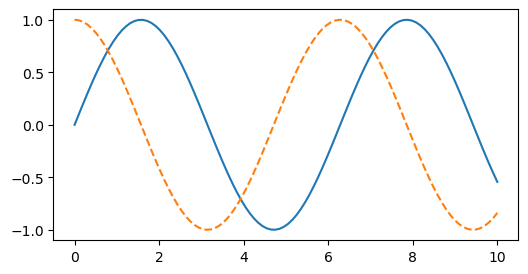

In [15]:
import numpy as np
x = np.linspace(0, 10, 100)

fig = plt.figure(figsize=(6, 3))
plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--');

### Saving Figures to File / 将图形保存为文件

One nice feature of Matplotlib is the ability to save figures in a wide variety of formats.
Saving a figure can be done using the ``savefig()`` command.

🐍 fig.savefig() 命令将图形保存为文件

For example, to save the previous figure as a PNG file, you can run this:

In [16]:
fig.savefig('b04_fig/b04_my_figure_3.png')

We now have a file called ``my_figure.png`` in the current working directory:

In [8]:
!ls -lh b04_fig/b04_my_figure.png

Der Befehl "ls" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


To confirm that it contains what we think it contains, let's use the IPython ``Image`` object to display the contents of this file:

🐍 可以用 IPython 的 Image 对象来显示文件内容

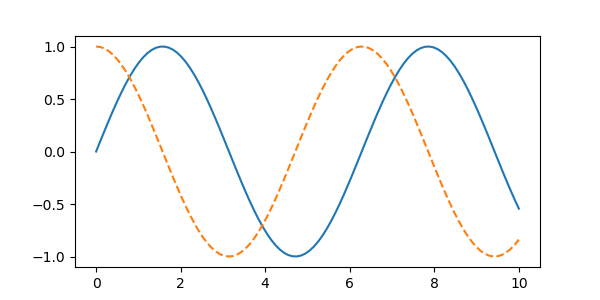

In [18]:
from IPython.display import Image
Image('b04_fig/b04_my_figure_4.png')

In ``savefig()``, the file format is inferred from the extension of the given filename.
Depending on what backends you have installed, many different file formats are available.
The list of supported file types can be found for your system by using the following method of the figure canvas object:

🐍 在 savefig() 里面，保存的图片文件格式就是文件的扩展名。Matplotlib 支持许多图形格式，具体格式由操作系统已安装的图形显示接口决定。你可以通过 canvas 对象的方法查看系统支持的文件格式：

In [19]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

Note that when saving your figure, it's not necessary to use ``plt.show()`` or related commands discussed earlier.

🐍 需要注意的是，当你保存图形文件时，不需要使用 plt.show() 或者前面介绍过的命令

## Two Interfaces for the Price of One / 两种画图接口

A potentially confusing feature of Matplotlib is its dual interfaces: a convenient MATLAB-style state-based interface, and a more powerful object-oriented interface. We'll quickly highlight the differences between the two here.

🐍 两种画图接口：一个是便捷的 MATLAB 风格接口，另一个是功能更强大的面向对象接口。

### MATLAB-style Interface

Matplotlib was originally written as a Python alternative for MATLAB users, and much of its syntax reflects that fact.
The MATLAB-style tools are contained in the pyplot (``plt``) interface.
For example, the following code will probably look quite familiar to MATLAB users:

🐍 Matplotlib 最初作为 MATLAB 用户的 Python 替代品， 许多语法都和 MATLAB 类似。MATLAB风格的工具位于 pyplot（plt）接口中。

🐍 fig = plt.figure(), ax = plt.axes()

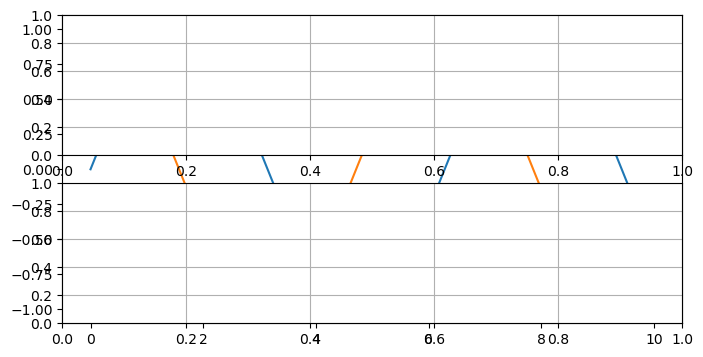

In [20]:
fig = plt.figure(figsize=(8, 4))  # create a plot figure

ax = plt.axes()

# create the first of two panels and set current axis
plt.subplot(2, 1, 1) # (rows, columns, panel number)
ax.plot(x, np.sin(x))
plt.grid()

# create the second panel and set current axis
plt.subplot(2, 1, 2)
ax.plot(x, np.cos(x));
plt.grid()

It is important to note that this interface is *stateful*: it keeps track of the "current" figure and axes, which are where all ``plt`` commands are applied.
You can get a reference to these using the ``plt.gcf()`` (get current figure) and ``plt.gca()`` (get current axes) routines.

🐍 这种接口最重要的特性是有状态的（stateful）：它会持续跟踪“当前的”图形和坐标轴，所有 plt 命令都可以应用。

🐍 plt.gcf()（获取当前图形）和 plt.gca()（获取当前坐标轴）来查看具体信息。

While this stateful interface is fast and convenient for simple plots, it is easy to run into problems.
For example, once the second panel is created, how can we go back and add something to the first?
This is possible within the MATLAB-style interface, but a bit clunky.
Fortunately, there is a better way.

### Object-oriented interface / 面向对象接口

The object-oriented interface is available for these more complicated situations, and for when you want more control over your figure.
Rather than depending on some notion of an "active" figure or axes, in the object-oriented interface the plotting functions are *methods* of explicit ``Figure`` and ``Axes`` objects.
To re-create the previous plot using this style of plotting, you might do the following:

🐍 面向对象接口可以适应更复杂的场景，更好地控制你自己的图形。

🐍 在面向对象接口中，画图函数不再受到当前“活动”图形或坐标轴的限制，而变成了显式的 Figure 和 Axes 的方法。

🐍 fig, ax = plt.subplots()

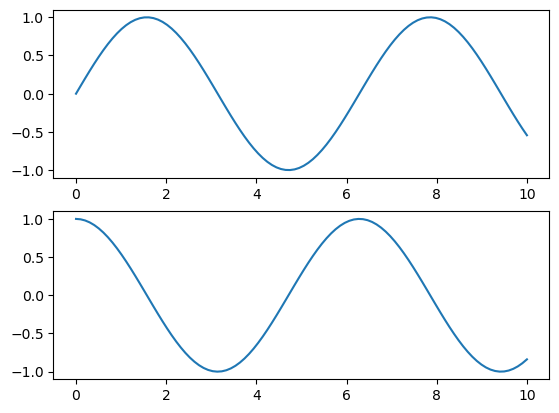

In [12]:
# First create a grid of plots
# ax will be an array of two Axes objects
fig, ax = plt.subplots(2)

# Call plot() method on the appropriate object
ax[0].plot(x, np.sin(x))
ax[1].plot(x, np.cos(x));

For more simple plots, the choice of which style to use is largely a matter of preference, but the object-oriented approach can become a necessity as plots become more complicated.
Throughout this chapter, we will switch between the MATLAB-style and object-oriented interfaces, depending on what is most convenient.
In most cases, the difference is as small as switching ``plt.plot()`` to ``ax.plot()``, but there are a few gotchas that we will highlight as they come up in the following sections.

🐍 选择哪种绘图风格主要看个人喜好，但是在画比较复杂的图形时，面向对象方法会更方便。

<!--NAVIGATION-->
< [Further Resources](03.13-Further-Resources.ipynb) | [Contents](Index.ipynb) | [Simple Line Plots](04.01-Simple-Line-Plots.ipynb) >